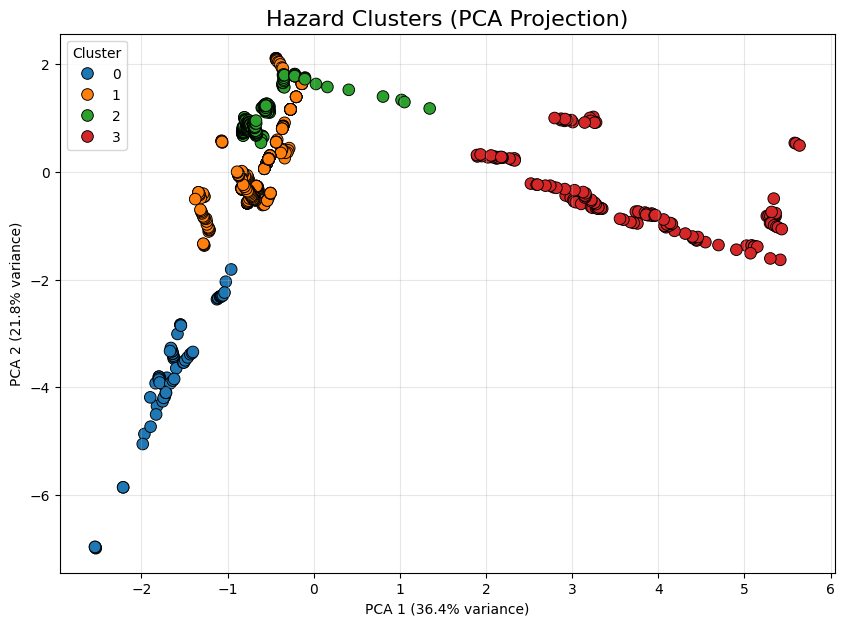

Explained variance: [0.36357826 0.21800795]


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------
# STEP 1 — Load cluster table (aggregated hazard features)
# ------------------------------------------------

features = pd.read_csv("HAZARD_CLUSTER_TABLE.csv")

# ------------------------------------------------
# STEP 2 — Identify numerical feature columns
# ------------------------------------------------

feature_cols = [col for col in features.columns if col not in ["hazard_id", "cluster"]]

X = features[feature_cols].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------
# STEP 3 — PCA Reduction
# ------------------------------------------------

pca = PCA(n_components=2)
proj = pca.fit_transform(X_scaled)

# Add PCA columns
features["PCA1"] = proj[:, 0]
features["PCA2"] = proj[:, 1]

# ------------------------------------------------
# STEP 4 — PCA Plot
# ------------------------------------------------

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=features,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="tab10",
    s=70,
    edgecolor="black",
)

plt.title("Hazard Clusters (PCA Projection)", fontsize=16)
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid(alpha=0.3)
plt.legend(title="Cluster")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)